# Califonia Housing prices 
# median House prices for Califonia districts derived from the 1990 census.

In [1]:
# importing the python labraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import (
mean_absolute_error,
root_mean_squared_error,
r2_score
)

In [2]:
# Confrigurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = r"C:\Users\rohit\Downloads\housing.csv"   # update path for a different dataset
TARGET_COL = "median_house_value" # target column name

# 2.Load data set

In [3]:
df = pd.read_csv(CSV_PATH)

In [4]:
print("DaaFrame shape:", df.shape)

DaaFrame shape: (20640, 10)


In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


# 3.Exploratory Data Analysis (EDA)

In [6]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

# column details:
1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [7]:
# basic data overview\ information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", TARGET_COL)
print("numberical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: median_house_value
numberical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


In [9]:
# missing values analysis
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [10]:
# check presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.250    128
-118.370    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
33.980    162
34.110    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

In [11]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of dublicate rows:", num_duplicates)

# (optional) drop duplicates if present 
# df = df.drop_duplicates()
# print("shape after dropping duplicates:", df.shape)


Number of dublicate rows: 0


In [12]:
# descriptive stat
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.000,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.540,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.330,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.000,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.000,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000


# Data Visualization 

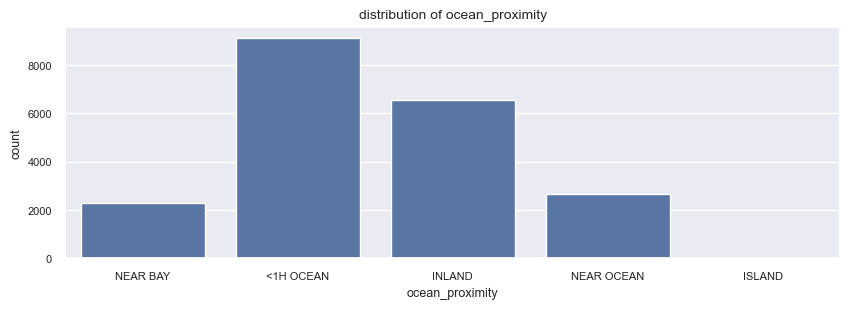

In [13]:
# countplot for catgorical columns
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=col, data=df)
    plt.title(f"distribution of {col}")
    plt.show()

In [14]:
# that is houses number for present grap
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


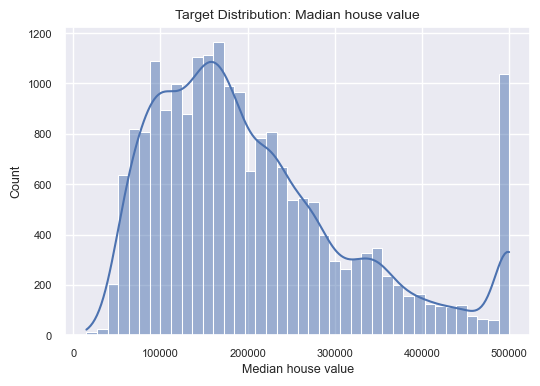

In [15]:
# target column distribution
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)  # KDE -Karnel destimation estimation
plt.title("Target Distribution: Madian house value")
plt.xlabel("Median house value")
plt.show()

In [16]:
# higher cap
df [TARGET_COL].value_counts()

median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
34200.000       1
46200.000       1
352000.000      1
307900.000      1
385200.000      1
Name: count, Length: 3842, dtype: int64

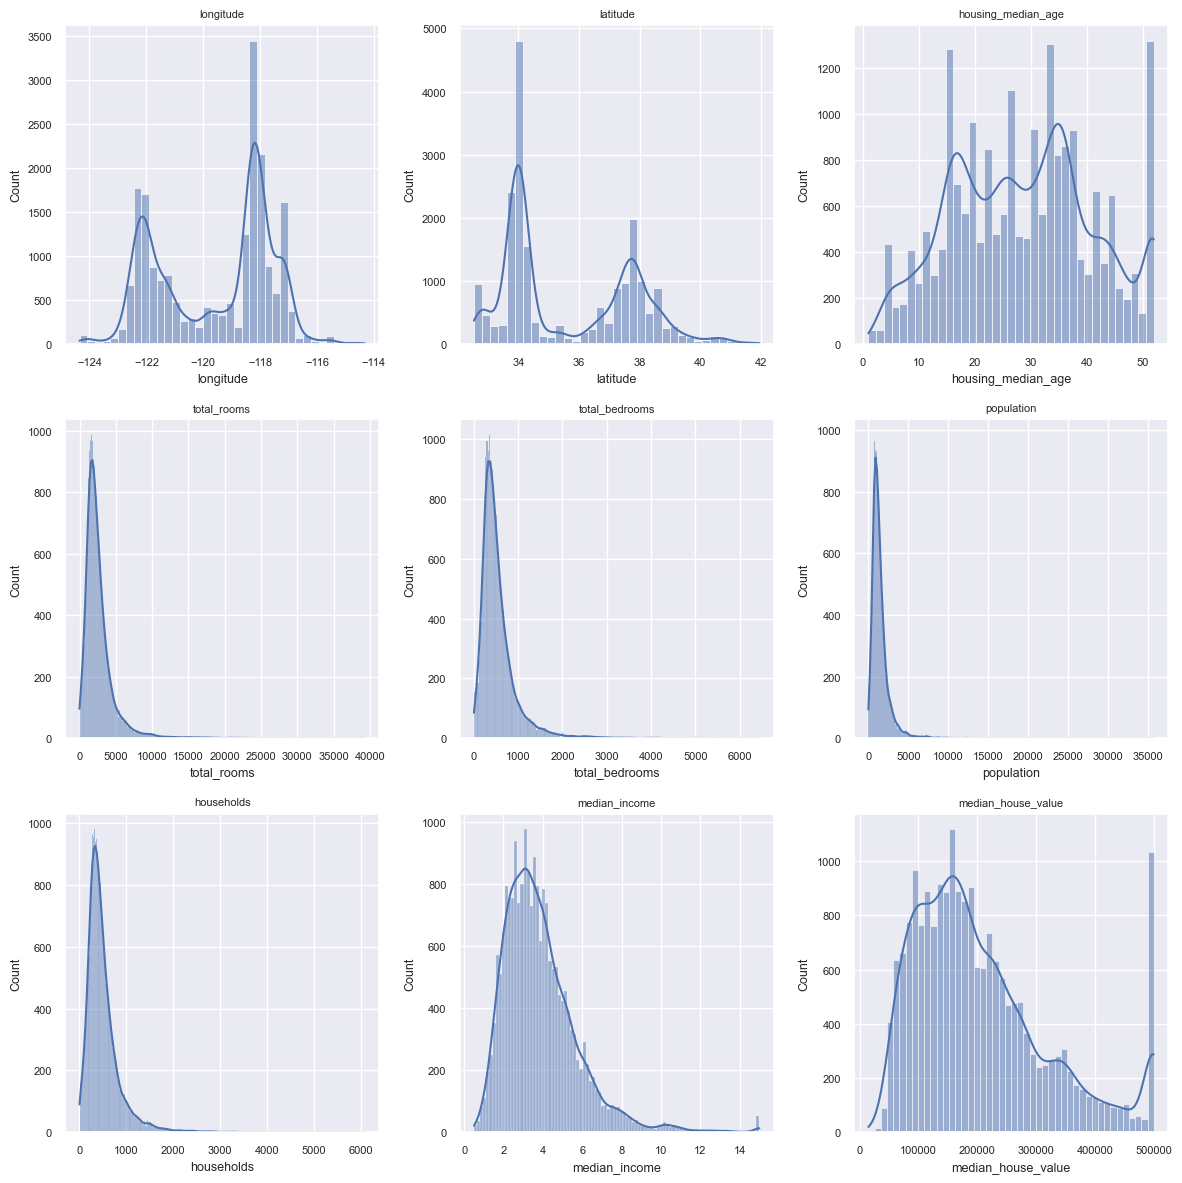

In [17]:
# hisplot plot  - distribution
import math 
num_cols = df.select_dtypes(include="number").columns

n = len(num_cols)
cols = 3 
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12,12))

axes = axes.flatten()
 # plot histograms
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col,fontsize=8)

# hide unused axes
for j in range(n, len(axes)):
    axes[j].set_visible(False)

# IMPORTANT: outside both loops
plt.tight_layout()
plt.show()

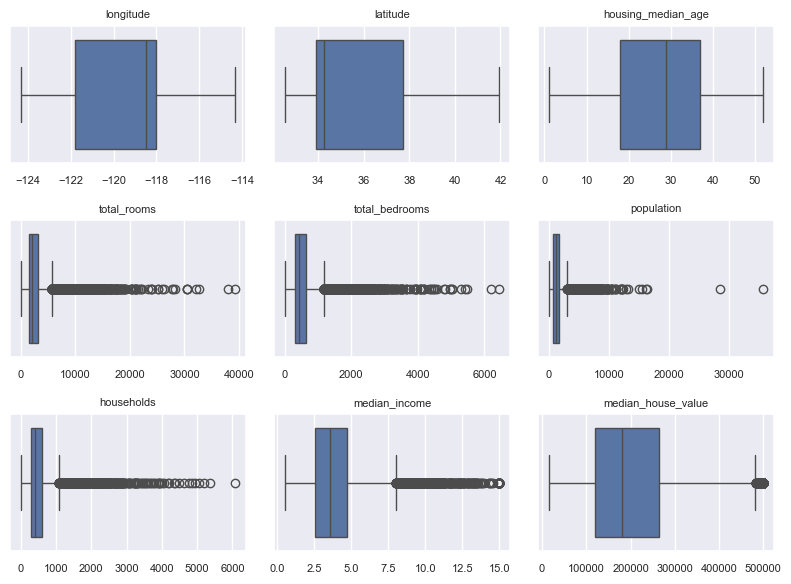

In [18]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

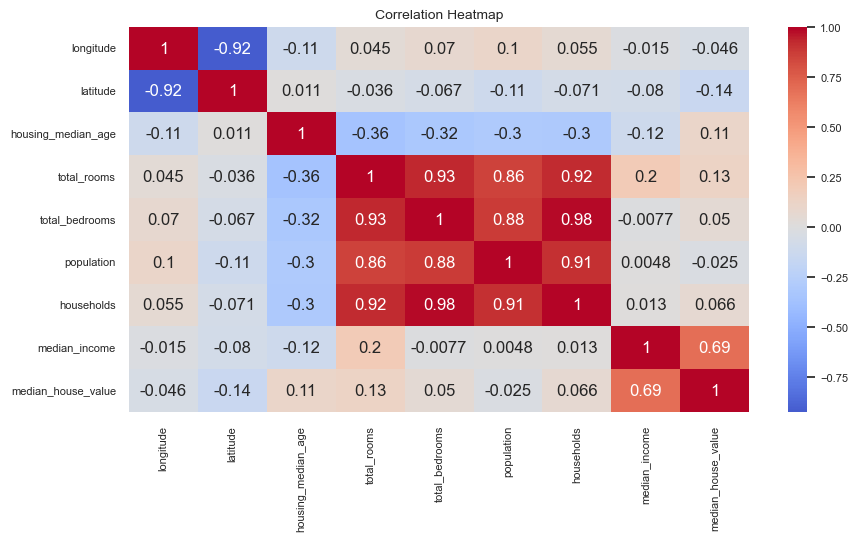

In [19]:
# identify presence of highly correleted columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
# correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


#  Key Insights from EDA:
 . dataset has numeric + one categorical feature (ocean_proximity)
 . only total_bedrooms has missing values
 . target (madian_house_values) is right-skewa and capped
 . several features show stong skew and outliers
 . median_income is the strongest predictor
 . high multicollinearity among room and population features

# Preprocessing & evaluation plam
1. median impulation for missing values
2. one-hot encoding for linear models
3. feature scalling for linear models
4. use pipelines to avoid data lekage 
5. baseline model -> cv model  selection -> hyperparameter tunning
6. primary metrics: RMSE, secondary: MAE and Rsquare
7. final  evaluation only on test set

# 4.Data Preprocessing 

In [21]:
# Separate features and target
x = df.drop(columns=[TARGET_COL])
y= df[TARGET_COL]

In [22]:
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [23]:
y.head()

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

In [24]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [25]:
print("Train shape:", x_train.shape)

print("Test shape:", x_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


# Preprocessing pipeline

In [26]:
numerical_features = x_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("numericcal features:", numerical_features)
print("categorical features:", categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

#preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

numericcal features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
categorical features: ['ocean_proximity']


#  5. Baseline model(no cv, no Tuning)

In [27]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [28]:
# preprocess the data and train the baseline model
baseline_pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

# Evaluation of baseline model

In [29]:
train_baseline_pred = baseline_pipe.predict(x_train)
test_baseline_pred = baseline_pipe.predict(x_test)


In [30]:
train_baseline_pred[:5]

array([188628.0772436 , 290379.8948687 , 250985.48476349, 146878.07878194,
       165789.41368924])

In [31]:
y_train[:5]

14196   103000.000
8267    382100.000
17445   172600.000
14265    93400.000
2271     96500.000
Name: median_house_value, dtype: float64

In [32]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n== TRAIN BASELINE METRICS (LinearRegression) ==")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"R2  : {train_baseline_r2:.3f}")


== TRAIN BASELINE METRICS (LinearRegression) ==
RMSE: 68433.937
MAE : 49594.842
R2  : 0.650


In [33]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n== TRAIN BASELINE METRICS (LinearRegression) ==")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")


== TRAIN BASELINE METRICS (LinearRegression) ==
RMSE: 70059.193
MAE : 50670.489
R2  : 0.625


# 6. Model selection & Optimization

In [34]:
# Models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state= RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "HistGB": HistGradientBoostingRegressor()
}

In [35]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [36]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [37]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, x_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })

# short based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("=== CV Model Comparison ===")
print(cv_results)

=== CV Model Comparison ===
              model   cv_rmse    cv_mae  cv_r2
4            HistGB 48416.182 32378.054  0.825
3      RandomForest 49478.945 32332.066  0.817
1             Ridge 68595.617 49664.331  0.648
2             Lasso 68603.233 49667.263  0.648
0  LinearRegression 68604.163 49667.159  0.648


In [38]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
4,HistGB,48416.182,32378.054,0.825
3,RandomForest,49478.945,32332.066,0.817
1,Ridge,68595.617,49664.331,0.648
2,Lasso,68603.233,49667.263,0.648
0,LinearRegression,68604.163,49667.159,0.648


In [39]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model:", best_model_name)
print("CV RMSE:", best_rmse)

Best model based on CV RMSE:
Model: HistGB
CV RMSE: 48416.18151764963


 # Best Model: HistGradiantBoostingRegressor

# 7. Hyperparameter Tuning

In [40]:
hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [41]:
# hyperparameter combination
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.01],
    "model__max_depth": [None, 3, 6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

In [42]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

In [43]:
# perform grid search
grid.fit(x_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income'...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__l2_regularization': [0.0, 0.1, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.01],
                         'model__max_depth': [None, 3, 6],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [44]:
print("\n=== TUNED HistGB (CV) ===")
print("Best CV RMSE:", -grid.best_score_)
print("Best Params:", grid.best_params_)


=== TUNED HistGB (CV) ===
Best CV RMSE: 48467.54080495553
Best Params: {'model__l2_regularization': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


# Retraining with best paams

In [45]:
hgb_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(
            l2_regularization=0.1,
            learning_rate=0.1,
            max_depth=None,
            max_leaf_nodes=63,
            min_samples_leaf=20
        ))
    ]
)

In [46]:
# train best model on entire traning data (can also be done with refiit=true in grid search)
hgb_best.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63))])

# 9.Final Evaluation 

In [47]:
train_final_pred = hgb_best.predict(x_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Train Performance ===")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Train Performance ===
RMSE: 36169.876
MAE : 24512.425
R2  : 0.902


In [48]:
test_final_pred = hgb_best.predict(x_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Train Performance ===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Train Performance ===
RMSE: 46787.448
MAE : 30797.794
R2  : 0.833


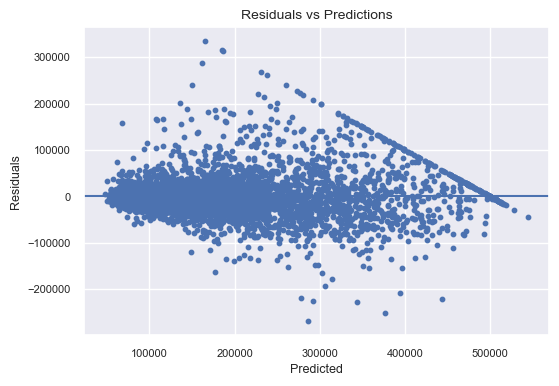

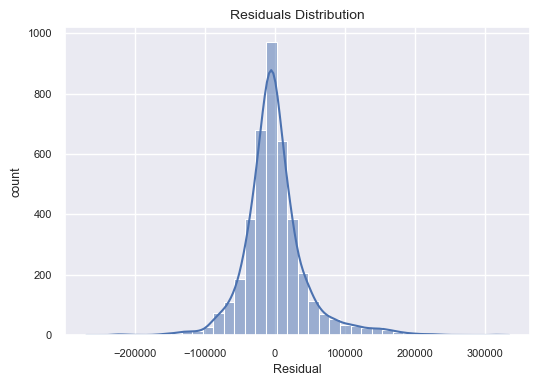

In [49]:
# residual plot 
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals,  s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.ylabel("count")
plt.show()

# 10. Building a pradictive system

In [50]:

def predict_house_price(
    model,
    longitude: float,
    latitude: float,
    housing_median_age: float,
    total_rooms: float,
    total_bedrooms: float,
    population: float,
    households: float,
    median_income: float,
    ocean_proximity: str
) -> float:

    new_row = pd.DataFrame({
        "longitude": [longitude],
        "latitude": [latitude],
        "housing_median_age": [housing_median_age],
        "total_rooms": [total_rooms],
        "total_bedrooms": [total_bedrooms],
        "population": [population],
        "households": [households],
        "median_income": [median_income],
        "ocean_proximity": [ocean_proximity]
    })

    return float(model.predict(new_row)[0])

In [51]:
# example inference 
example_pred = predict_house_price(
    model=hgb_best,
    longitude=-122.230,
    latitude=37.880,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
)

print("\nExample Prediction:", round(example_pred, 2))


Example Prediction: 452497.25


In [53]:
# Fearture Engineering- ratio features

df["rooms_per_household"] = (
    df["total_rooms"] / df["households"]
)

df["bedrooms_per_room"] = (
    df["total_bedrooms"] / df["total_rooms"]
)

df["population_per_household"] = (
    df["population"] / df["households"]
)

df[
    [
        "rooms_per_household",
        "bedrooms_per_room",
        "population_per_household"
    ]
].head()

,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984,0.147,2.556
1,6.238,0.156,2.110
2,8.288,0.130,2.802
3,5.817,0.184,2.548
4,6.282,0.172,2.181


In [55]:
# Correlation with Target
# this code are use check every numerical features and median_house_value ralationship

correlation = df.corr(
    numeric_only=True
)["median_house_value"].sort_values(
    ascending=False
)

print(correlation)

median_house_value          1.000
median_income               0.688
rooms_per_household         0.152
total_rooms                 0.134
housing_median_age          0.106
households                  0.066
total_bedrooms              0.050
population_per_household   -0.024
population                 -0.025
longitude                  -0.046
latitude                   -0.144
bedrooms_per_room          -0.256
Name: median_house_value, dtype: float64


In [57]:
# Log Transformation of Target Variable
# this code works on original target median_house_value thsi new transformed column added for log_median_house_value this are work is house-price values scale low 
import numpy as np

df["log_median_house_value"] = np.log1p(
    df["median_house_value"]
)

df[
    ["median_house_value", "log_median_house_value"]
].head()

,median_house_value,log_median_house_value
0,452600.000,13.023
1,358500.000,12.790
2,352100.000,12.772
3,341300.000,12.741
4,342200.000,12.743


In [59]:
# Train-Test Split
# x- is work now give model feartures
# y- is work now your target median_house_value 
# 80% data- traning
#20% data- testing
# random_state=42 any time same split
from sklearn.model_selection import train_test_split

X = df.drop(
    columns=["median_house_value", "log_median_house_value"]
)

y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (16512, 12)
X_test shape : (4128, 12)
y_train shape: (16512,)
y_test shape : (4128,)


In [60]:
# Step 5: Preprocessing
# this code display the output your ocean_proximity he is categorical feature and another are numerical columns numeric features.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

Categorical Features:
['ocean_proximity']


In [61]:
# Step 6: Create Preprocessing Pipeline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Numerical Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


In [62]:
# Step 7: HistGradientBoosting with Log Target

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
import numpy as np

# Log transformation of training target
y_train_log = np.log1p(y_train)

# Model
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

# Complete pipeline
hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", hgb_model)
])

# Train model
hgb_pipeline.fit(X_train, y_train_log)

print("HistGradientBoosting Model trained successfully!")

HistGradientBoosting Model trained successfully!


In [63]:
# Step 8: Prediction and Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict log values
y_pred_log = hgb_pipeline.predict(X_test)

# Convert predictions back to original price
y_pred = np.expm1(y_pred_log)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------------")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

Model Performance
------------------------
MAE  : 29677.524499661773
RMSE : 46929.11029188836
R²   : 0.8319348058997079


In [64]:
# Step 9: Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_iter": [200, 300, 500],
    "model__max_bins": [100, 150, 255]
}

grid_search = GridSearchCV(
    hgb_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train_log)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV R²:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_bins': 255, 'model__max_iter': 500}

Best CV R²:
0.8503349183495154


In [66]:
# Step 10: Evaluate Best Tuned Model

best_model = grid_search.best_estimator_

# Prediction on test data
y_pred_log_tuned = best_model.predict(X_test)

# Convert back to original price
y_pred_tuned = np.expm1(y_pred_log_tuned)

# Evaluation
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Model Performance")
print("-----------------------------")
print("MAE  :", mae_tuned)
print("RMSE :", rmse_tuned)
print("R²   :", r2_tuned)

Tuned Model Performance
-----------------------------
MAE  : 29301.618210938686
RMSE : 46450.188796323026
R²   : 0.8353475842243958


In [67]:
# Step 11: Check XGBoost

import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 2.1.1


In [68]:
# Step 12: XGBoost Model

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

# Train using log-transformed target
xgb_pipeline.fit(X_train, y_train_log)

print("XGBoost Model trained successfully!")

XGBoost Model trained successfully!


In [72]:
# Step 12B: Transform Data for XGBoost

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape :", X_train_processed.shape)
print("Testing data shape  :", X_test_processed.shape)

Training data shape : (16512, 16)
Testing data shape  : (4128, 16)


In [74]:
# Step 12C: Train XGBoost on Processed Data

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train on log-transformed target
xgb_model.fit(
    X_train_processed,
    y_train_log
)

print("XGBoost Model trained successfully!")

XGBoost Model trained successfully!


In [75]:
# Step 13: XGBoost Prediction and Evaluation

# Predict log values
y_pred_log_xgb = xgb_model.predict(X_test_processed)

# Convert predictions back to original price
y_pred_xgb = np.expm1(y_pred_log_xgb)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Model Performance")
print("-----------------------------")
print("MAE  :", mae_xgb)
print("RMSE :", rmse_xgb)
print("R²   :", r2_xgb)

XGBoost Model Performance
-----------------------------
MAE  : 28795.999057503635
RMSE : 45685.91450335432
R²   : 0.8407212695680952


In [76]:
# Step 14: Create Error Analysis Table

error_df = X_test.copy()

error_df["actual_price"] = y_test.values
error_df["predicted_price"] = y_pred_xgb

error_df["error"] = (
    error_df["actual_price"] - error_df["predicted_price"]
)

error_df["absolute_error"] = (
    abs(error_df["error"])
)

error_df[
    [
        "actual_price",
        "predicted_price",
        "error",
        "absolute_error"
    ]
].head(10)

,actual_price,predicted_price,error,absolute_error
20046,47700.000,53462.223,-5762.223,5762.223
3024,45800.000,72120.992,-26320.992,26320.992
15663,500001.000,437868.219,62132.781,62132.781
20484,218600.000,230326.750,-11726.750,11726.750
9814,278000.000,246665.016,31334.984,31334.984
13311,158700.000,160746.156,-2046.156,2046.156
7113,198200.000,223323.562,-25123.562,25123.562
7668,157500.000,159290.000,-1790.000,1790.000
18246,340000.000,265304.688,74695.312,74695.312
5723,446600.000,453543.625,-6943.625,6943.625


In [77]:
# Step 15: Location-wise Error Analysis

location_error = (
    error_df
    .groupby("ocean_proximity")["absolute_error"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

location_error.columns = [
    "Average_Absolute_Error",
    "Number_of_Houses"
]

print(location_error)

                 Average_Absolute_Error  Number_of_Houses
ocean_proximity                                          
ISLAND                       151247.469                 1
NEAR OCEAN                    35822.539               572
NEAR BAY                      34401.143               436
<1H OCEAN                     31082.617              1795
INLAND                        20722.016              1324


In [78]:
# Step 16: Price Range-wise Error Analysis

error_df["price_range"] = pd.cut(
    error_df["actual_price"],
    bins=[0, 100000, 200000, 300000, 400000, 500000, 600000, float("inf")],
    labels=[
        "0-100K",
        "100K-200K",
        "200K-300K",
        "300K-400K",
        "400K-500K",
        "500K-600K",
        "600K+"
    ]
)

price_error = (
    error_df
    .groupby("price_range", observed=True)["absolute_error"]
    .agg(["mean", "count"])
)

price_error.columns = [
    "Average_Absolute_Error",
    "Number_of_Houses"
]

print(price_error)

             Average_Absolute_Error  Number_of_Houses
price_range                                          
0-100K                    14795.023               739
100K-200K                 19912.671              1682
200K-300K                 31209.784               956
300K-400K                 48744.837               412
400K-500K                 68884.329               160
500K-600K                 75432.011               179


In [79]:
# Step 17: Create Spatial Groups

# Create location-based groups using latitude and longitude

df["location_group"] = (
    df["latitude"].round(1).astype(str)
    + "_"
    + df["longitude"].round(1).astype(str)
)

print("Number of location groups:", df["location_group"].nunique())

print("\nSample location groups:")
print(df["location_group"].head())

Number of location groups: 1563

Sample location groups:
0    37.9_-122.2
1    37.9_-122.2
2    37.8_-122.2
3    37.8_-122.2
4    37.8_-122.2
Name: location_group, dtype: object


In [80]:
# Step 18: Spatial / Grouped Validation

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df,
        groups=df["location_group"]
    )
)

print("Spatial Training samples:", len(train_idx))
print("Spatial Testing samples :", len(test_idx))

print(
    "Training location groups:",
    df.iloc[train_idx]["location_group"].nunique()
)

print(
    "Testing location groups :",
    df.iloc[test_idx]["location_group"].nunique()
)

Spatial Training samples: 16608
Spatial Testing samples : 4032
Training location groups: 1250
Testing location groups : 313


In [81]:
# Final Prediction Function

def predict_house_price(
    longitude,
    latitude,
    housing_median_age,
    total_rooms,
    total_bedrooms,
    population,
    households,
    median_income,
    ocean_proximity
):
    
    # Create input DataFrame
    input_data = pd.DataFrame({
        "longitude": [longitude],
        "latitude": [latitude],
        "housing_median_age": [housing_median_age],
        "total_rooms": [total_rooms],
        "total_bedrooms": [total_bedrooms],
        "population": [population],
        "households": [households],
        "median_income": [median_income],
        "ocean_proximity": [ocean_proximity]
    })
    
    # Feature engineering
    input_data["rooms_per_household"] = (
        input_data["total_rooms"] /
        input_data["households"]
    )
    
    input_data["bedrooms_per_room"] = (
        input_data["total_bedrooms"] /
        input_data["total_rooms"]
    )
    
    input_data["population_per_household"] = (
        input_data["population"] /
        input_data["households"]
    )
    
    # Preprocess
    input_processed = preprocessor.transform(input_data)
    
    # Predict log price
    prediction_log = xgb_model.predict(input_processed)
    
    # Convert back to original price
    prediction = np.expm1(prediction_log)
    
    return prediction[0]


# Example Prediction
price = predict_house_price(
    longitude=-122.23,
    latitude=37.88,
    housing_median_age=41,
    total_rooms=880,
    total_bedrooms=129,
    population=322,
    households=126,
    median_income=8.3252,
    ocean_proximity="NEAR BAY"
)

print("Predicted House Price: $", round(price, 2))

Predicted House Price: $ 416208.84
